# Phân tích tác động của AI đến hoạt động hỏi đáp lập trình trên Stack Overflow

*IE313 – Phân tích dữ liệu · Đồ án môn học*

## 01. Giới thiệu

- **Đề tài:** so sánh hoạt động hỏi đáp lập trình trên Stack Overflow **trước** và **sau** khi AI (ChatGPT) trở nên phổ biến.
- **Mục tiêu:** phân tích số câu hỏi, số câu trả lời, số câu trả lời trên mỗi câu hỏi, mức độ tương tác, tỷ lệ câu hỏi có câu trả lời được chấp nhận và cơ cấu tag lập trình.
- **Câu hỏi nghiên cứu:** Hoạt động hỏi đáp lập trình trên Stack Overflow thay đổi như thế nào sau khi AI phổ biến?
- **Phạm vi kết luận:** so sánh theo thời gian không đủ để xác định AI là nguyên nhân của các thay đổi quan sát được.


## 02. Dữ liệu

- **Nguồn:** API chính thức của Stack Exchange (`api.stackexchange.com/2.3`, site `stackoverflow`). Thông tin lần thu thập được lưu trong `data/collection_info.json`; notebook đọc các file dữ liệu đã thu thập.
- **Cấu trúc dữ liệu:** API chỉ cho 300 lượt gọi/ngày và không cho tải toàn bộ ~24 triệu câu hỏi. Nhưng API **đếm chính xác** được số câu hỏi/câu trả lời, nên dữ liệu chia làm 3 phần:
  - `so_monthly_totals.csv` – số **Questions** và **Answers** đăng mỗi tháng, 60 tháng (01/2021 → 12/2025). **Đếm chính xác, toàn bộ Stack Overflow.**
  - `so_questions_sample.csv` – **mẫu ngẫu nhiên** 100 câu hỏi/tháng × 60 tháng = 6,000 câu hỏi (có Score, AnswerCount, AcceptedAnswerId, Tags…). **Ước lượng, có sai số.**
  - `so_tag_counts.csv` – số câu hỏi của từng tag công nghệ trong mỗi giai đoạn. **Đếm chính xác.**
- **Cách lấy mẫu:** mỗi tháng chọn một thời điểm ngẫu nhiên rồi lấy 100 câu hỏi đăng liên tiếp từ đó. Tháng 01/2021 có 139,827 câu hỏi nhưng chỉ lấy 100, nên mỗi câu hỏi mẫu được gán **trọng số** = số câu hỏi thật của tháng ÷ 100 (nó "đại diện" cho từng ấy câu hỏi thật). Nhờ vậy tháng đông câu hỏi được tính đúng tỷ trọng.
- **Sai số (±):** các chỉ số tính từ mẫu được trình bày kèm biên sai số ước lượng ở mức tin cậy 95%.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
from IPython.display import Markdown, display

DATA_DIR = Path("data")
AI_START = "2022-12"
AI_DATE = pd.Timestamp("2022-11-30")
PERIODS = ["Before AI", "After AI"]

C_BEFORE, C_AFTER = "#2a78d6", "#eb6834"
C_UP, C_DOWN = "#2a78d6", "#e34948"
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "savefig.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.labelsize": 10.5, "legend.frameon": False, "figure.dpi": 100,
})

In [2]:
def pct_change(before, after):
    """% thay đổi = (After - Before) / Before x 100"""
    return (after - before) / before * 100

def wmean(x, w):
    """Trung bình có trọng số (mỗi câu hỏi mẫu đại diện cho w câu hỏi thật)."""
    return float(np.average(x, weights=w))

def wmedian(x, w):
    """Trung vị có trọng số."""
    order = np.argsort(x.values)
    cum = np.cumsum(w.values[order]) / w.sum()
    return float(x.values[order][np.searchsorted(cum, 0.5)])

def wmargin(x, w):
    """Sai số ± của trung bình có trọng số (độ tin cậy 95%)."""
    m = np.average(x, weights=w)
    return float(1.96 * np.sqrt(np.sum(w.values ** 2 * (x.values - m) ** 2)) / w.sum())

def beyond_error(before, after, m_before, m_after):
    """True nếu khác biệt Before/After lớn hơn sai số của mẫu (tức không chỉ do may rủi khi lấy mẫu)."""
    return bool(abs(after - before) > np.hypot(m_before, m_after))

def thousands(v, _=None):
    return f"{v:,.0f}"

def fmt_cell(v):
    """Định dạng số trong bảng: có dấu phẩy ngăn cách hàng nghìn, ô trống hiện '–'."""
    if isinstance(v, str):
        return v
    if pd.isna(v):
        return "–"
    return f"{v:,.1f}" if isinstance(v, float) else f"{v:,}"

def show(text):
    """Hiển thị kết quả dạng Markdown."""
    display(Markdown(text))

def plot_monthly(ax, series, title, ylabel, lab_before, lab_after, avg_before, avg_after, int_axis=True, legend_loc="upper right"):
    """Line chart theo tháng: xanh = Before AI, cam = After AI, vạch dọc = ChatGPT ra mắt, đường đứt = trung bình giai đoạn."""
    before = series[series.index < pd.Timestamp(AI_START + "-01")]
    after = series[series.index >= before.index[-1]]
    ax.plot(before.index, before.values, color=C_BEFORE, lw=2, label=lab_before)
    ax.plot(after.index, after.values, color=C_AFTER, lw=2, label=lab_after)
    ax.hlines(avg_before, before.index[0], before.index[-1], color=C_BEFORE, lw=1, ls="--")
    ax.hlines(avg_after, AI_DATE, series.index[-1], color=C_AFTER, lw=1, ls="--")
    ax.plot([], [], color=MUTED, lw=1, ls="--", label="Đường đứt: trung bình giai đoạn")
    ax.axvline(AI_DATE, color=MUTED, lw=1, ls=":")
    ax.set_ylim(0, series.max() * 1.12)
    ax.text(AI_DATE, series.max() * 1.10, "  ChatGPT ra mắt\n  30/11/2022", color=INK2, va="top", ha="left", fontsize=9.5)
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%Y"))
    ax.set_title(title); ax.set_xlabel("Tháng đăng (UTC)"); ax.set_ylabel(ylabel)
    ax.legend(loc=legend_loc, fontsize=9.5)
    if int_axis:
        ax.yaxis.set_major_formatter(FuncFormatter(thousands))

def plot_bars(ax, values, margins, title, ylabel, fmt):
    """Bar chart 2 cột Before/After, thanh đen = ± sai số ước lượng."""
    bars = ax.bar(PERIODS, values, width=0.5, color=[C_BEFORE, C_AFTER], yerr=margins, capsize=6,
                  error_kw={"ecolor": INK2, "elinewidth": 1.2})
    for bar, v, m in zip(bars, values, margins):
        ax.annotate(fmt(v), (bar.get_x() + bar.get_width() / 2, v + m), xytext=(0, 4), textcoords="offset points",
                    ha="center", va="bottom", fontsize=11, fontweight="bold")
    ax.set_ylim(0, max(v + m for v, m in zip(values, margins)) * 1.2)
    ax.set_title(title); ax.set_ylabel(ylabel); ax.set_xlabel("Giai đoạn  ·  thanh đen = ± sai số ước lượng")
    ax.grid(axis="x", visible=False)

In [3]:
totals = pd.read_csv(DATA_DIR / "so_monthly_totals.csv")
sample = pd.read_csv(DATA_DIR / "so_questions_sample.csv",
                     usecols=["Id", "PostTypeId", "CreationDate", "Score", "ViewCount",
                              "AnswerCount", "AcceptedAnswerId", "Tags"],
                     parse_dates=["CreationDate"])
tag_counts = pd.read_csv(DATA_DIR / "so_tag_counts.csv")
info = json.load(open(DATA_DIR / "collection_info.json", encoding="utf-8"))

print(f"Thu thập từ {info['api']} (site {info['site']}) lúc {info['collected_at_utc']} UTC | seed lấy mẫu = {info['seed']}")
for name, d in [("so_monthly_totals", totals), ("so_questions_sample", sample), ("so_tag_counts", tag_counts)]:
    print(f"{name:20s}: {d.shape[0]:>5,} dòng × {d.shape[1]} cột | {d.memory_usage(deep=True).sum() / 1024:,.0f} KB")
print()
display(sample.dtypes.rename("Kiểu dữ liệu").to_frame().T)
display(sample.head(3))

Thu thập từ https://api.stackexchange.com/2.3 (site stackoverflow) lúc 2026-09-23 17:03:18 UTC | seed lấy mẫu = 42
so_monthly_totals   :    60 dòng × 3 cột | 4 KB
so_questions_sample : 6,000 dòng × 8 cột | 782 KB
so_tag_counts       :    62 dòng × 5 cột | 11 KB



,Id,PostTypeId,CreationDate,Score,ViewCount,AnswerCount,AcceptedAnswerId,Tags
Kiểu dữ liệu,int64,int64,datetime64[us],int64,int64,int64,float64,str


,Id,PostTypeId,CreationDate,Score,ViewCount,AnswerCount,AcceptedAnswerId,Tags
0,65816116,1,2021-01-20 19:13:45,0,482,1,65816373.0,python
1,65816124,1,2021-01-20 19:14:03,0,36,0,NaN,javascript;node.js;adonis.js
2,65816131,1,2021-01-20 19:14:22,1,530,0,NaN,python;color-blindness


### Kiểm tra các trường dữ liệu
Bảng dưới đối chiếu các trường cần thiết với dữ liệu hiện có.

In [4]:
needed = ["Id", "PostTypeId", "ParentId", "CreationDate", "Score", "ViewCount", "AnswerCount", "AcceptedAnswerId", "Tags", "Title", "Body"]
notes = {
    "PostTypeId": "= 1 (Question); Answers đếm riêng theo tháng qua API /answers",
    "ParentId": "chỉ có ở Answer; không lấy từng Answer -> liên kết Question-Answer qua AnswerCount",
    "Title": "không cần cho 6 phân tích -> không lấy",
    "Body": "không cần cho 6 phân tích -> không lấy",
    "ViewCount": "có, nhưng không dùng để so sánh (lý do ở mục 08)",
}
check = pd.DataFrame({"Trường": needed,
                      "Có trong dữ liệu": ["Có" if c in sample.columns else "Không" for c in needed],
                      "Ghi chú": [notes.get(c, "") for c in needed]})
display(check)

print("Liên kết Question - Answer: không có bảng Answer riêng; số Answers của từng câu hỏi lấy từ AnswerCount, "
      "tổng Answers theo tháng lấy từ API.")

,Trường,Có trong dữ liệu,Ghi chú
0,Id,Có,
1,PostTypeId,Có,= 1 (Question); Answers đếm riêng theo tháng q...
2,ParentId,Không,chỉ có ở Answer; không lấy từng Answer -> liên...
3,CreationDate,Có,
4,Score,Có,
5,ViewCount,Có,"có, nhưng không dùng để so sánh (lý do ở mục 08)"
6,AnswerCount,Có,
7,AcceptedAnswerId,Có,
8,Tags,Có,
9,Title,Không,không cần cho 6 phân tích -> không lấy


Liên kết Question - Answer: không có bảng Answer riêng; số Answers của từng câu hỏi lấy từ AnswerCount, tổng Answers theo tháng lấy từ API.


## 03. Làm sạch dữ liệu

### 3.1 Kiểm tra chất lượng dữ liệu
Kiểm tra dữ liệu **trước** khi phân tích: số dòng, khoảng thời gian, giá trị thiếu, trùng lặp, số Questions/Answers, số dữ liệu Before/After. Mốc Before/After (`AI_START`) được giải thích ở mục 04.

In [5]:
totals["Period"] = np.where(totals["Month"] >= AI_START, "After AI", "Before AI")
sample["Month"] = sample["CreationDate"].dt.strftime("%Y-%m")
sample["Period"] = np.where(sample["Month"] >= AI_START, "After AI", "Before AI")

print("DATA QUALITY CHECK")
print("-" * 78)
print(f"Number of records : {len(sample):,} câu hỏi mẫu | {len(totals)} tháng (tổng Questions/Answers) | {len(tag_counts)} dòng đếm tag")
print(f"Date range        : mẫu {sample['CreationDate'].min():%Y-%m-%d} -> {sample['CreationDate'].max():%Y-%m-%d} | tổng {totals['Month'].min()} -> {totals['Month'].max()}")
print(f"Questions count   : {totals['Questions'].sum():,} câu hỏi (đếm chính xác) | trong mẫu: {(sample['PostTypeId'] == 1).sum():,}")
print(f"Answers count     : {totals['Answers'].sum():,} câu trả lời (đếm chính xác) | tổng AnswerCount trong mẫu: {sample['AnswerCount'].sum():,}")
print(f"Duplicate records : {sample.duplicated().sum()} dòng trùng hoàn toàn | {sample['Id'].duplicated().sum()} Id trùng")
print()

print("Missing values (mẫu câu hỏi):")
raw = sample.drop(columns=["Month", "Period"])
missing = pd.DataFrame({"Số dòng thiếu": raw.isna().sum(), "% thiếu": (raw.isna().mean() * 100).round(1).astype(str) + "%"})
display(missing.T)
print("-> Chỉ AcceptedAnswerId có ô trống: nghĩa là câu hỏi CHƯA có câu trả lời được chấp nhận (không phải lỗi dữ liệu).")
print("   Sẽ tạo cột HasAccepted (True/False) ở bước 3.2.")
print()

print("Số lượng Before AI / After AI:")
counts = totals.groupby("Period").agg(Tháng=("Month", "count"), Questions=("Questions", "sum"), Answers=("Answers", "sum")).loc[PERIODS]
counts["Câu hỏi mẫu"] = sample.groupby("Period").size()
display(counts.map("{:,}".format))

print("Kiểm tra logic:")
print(" - Số câu hỏi mẫu mỗi tháng (các giá trị khác nhau):", [int(v) for v in sorted(sample.groupby("Month").size().unique())])
print(" - Có accepted answer nhưng AnswerCount = 0      :", int((sample["AcceptedAnswerId"].notna() & (sample["AnswerCount"] == 0)).sum()), "dòng")
print(" - ViewCount hoặc AnswerCount âm                 :", int(((sample["ViewCount"] < 0) | (sample["AnswerCount"] < 0)).sum()), "dòng")
print(" - Tháng nào có Answers < Questions?             :", totals.loc[totals["Answers"] < totals["Questions"], "Month"].tolist() or "không có")

DATA QUALITY CHECK
------------------------------------------------------------------------------
Number of records : 6,000 câu hỏi mẫu | 60 tháng (tổng Questions/Answers) | 62 dòng đếm tag
Date range        : mẫu 2021-01-20 -> 2025-12-12 | tổng 2021-01 -> 2025-12
Questions count   : 4,165,547 câu hỏi (đếm chính xác) | trong mẫu: 6,000
Answers count     : 5,486,140 câu trả lời (đếm chính xác) | tổng AnswerCount trong mẫu: 6,412
Duplicate records : 0 dòng trùng hoàn toàn | 0 Id trùng

Missing values (mẫu câu hỏi):


,Id,PostTypeId,CreationDate,Score,ViewCount,AnswerCount,AcceptedAnswerId,Tags
Số dòng thiếu,0,0,0,0,0,0,3695,0
% thiếu,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,61.6%,0.0%


-> Chỉ AcceptedAnswerId có ô trống: nghĩa là câu hỏi CHƯA có câu trả lời được chấp nhận (không phải lỗi dữ liệu).
   Sẽ tạo cột HasAccepted (True/False) ở bước 3.2.

Số lượng Before AI / After AI:


,Tháng,Questions,Answers,Câu hỏi mẫu
Period,,,,
Before AI,23,"2,773,389","3,580,645","2,300"
After AI,37,"1,392,158","1,905,495","3,700"


Kiểm tra logic:
 - Số câu hỏi mẫu mỗi tháng (các giá trị khác nhau): [100]
 - Có accepted answer nhưng AnswerCount = 0      : 0 dòng
 - ViewCount hoặc AnswerCount âm                 : 0 dòng
 - Tháng nào có Answers < Questions?             : không có


### 3.2 Làm sạch và lọc
Dữ liệu được lọc theo loại bài, khoảng thời gian, bản ghi trùng và giá trị thiếu. Bảng kết quả ghi số dòng bị loại ở từng bước. Riêng `AcceptedAnswerId` trống là thông tin có ý nghĩa nên **giữ lại** và chuyển thành `HasAccepted`.

### 3.3 Xác định câu hỏi lập trình
Stack Overflow là trang **chỉ dành cho lập trình**: mọi câu hỏi đều bắt buộc có ít nhất 1 tag công nghệ. Vì vậy tiêu chí lọc là *"câu hỏi có ít nhất 1 tag"*. Không lọc theo danh sách công nghệ cụ thể vì sẽ loại nhầm nhiều câu hỏi lập trình hợp lệ (xem số liệu bên dưới).

In [6]:
df = sample.copy()
log = []

def keep_rows(data, name, keep):
    """Giữ các dòng thoả điều kiện và ghi lại số dòng bị loại ở bước này."""
    log.append({"Bước lọc": name, "Số dòng trước": len(data), "Bị loại": int((~keep).sum())})
    return data[keep]

df = keep_rows(df, "PostTypeId = 1 (chỉ giữ Question)", df["PostTypeId"] == 1)
df = keep_rows(df, "CreationDate trong 2021-01 -> 2025-12", df["Month"].between("2021-01", "2025-12"))
df = keep_rows(df, "Bỏ Id trùng lặp", ~df["Id"].duplicated())
df = keep_rows(df, "Bỏ dòng thiếu Score / Tags / CreationDate", df[["Score", "Tags", "CreationDate"]].notna().all(axis=1))
df = keep_rows(df, "Programming question: có >= 1 tag", df["Tags"].str.strip() != "")
display(pd.DataFrame(log))

df["HasAccepted"] = df["AcceptedAnswerId"].notna()
df["Weight"] = df["Month"].map(totals.set_index("Month")["Questions"]) / df.groupby("Month")["Id"].transform("count")

tech_tags = set(tag_counts.loc[tag_counts["Group"] == "Programming", "Tag"])
has_tech = df["Tags"].str.split(";").apply(lambda t: bool(tech_tags & set(t)))
print(f"Nếu chỉ giữ câu hỏi có 1 trong {len(tech_tags)} tag công nghệ phổ biến, sẽ mất {(~has_tech).mean() * 100:.1f}% câu hỏi "
      "(vẫn là câu hỏi lập trình hợp lệ, vd hỏi về arrays, regex, json...) -> không lọc theo cách này.")
print()

n0, n1 = len(sample), len(df)
print(f"Original records: {n0:,}")
print(f"After filtering : {n1:,}")
print(f"Removed         : {(n0 - n1) / n0 * 100:.2f}%")
print(f"Final dataset   : {n1:,} câu hỏi mẫu ({df['Month'].nunique()} tháng × {n1 // df['Month'].nunique()} câu hỏi/tháng) "
      f"+ {len(totals)} tháng tổng Questions/Answers + {tag_counts['Tag'].nunique()} tag đếm chính xác")

,Bước lọc,Số dòng trước,Bị loại
0,PostTypeId = 1 (chỉ giữ Question),6000,0
1,CreationDate trong 2021-01 -> 2025-12,6000,0
2,Bỏ Id trùng lặp,6000,0
3,Bỏ dòng thiếu Score / Tags / CreationDate,6000,0
4,Programming question: có >= 1 tag,6000,0


Nếu chỉ giữ câu hỏi có 1 trong 25 tag công nghệ phổ biến, sẽ mất 36.3% câu hỏi (vẫn là câu hỏi lập trình hợp lệ, vd hỏi về arrays, regex, json...) -> không lọc theo cách này.

Original records: 6,000
After filtering : 6,000
Removed         : 0.00%
Final dataset   : 6,000 câu hỏi mẫu (60 tháng × 100 câu hỏi/tháng) + 60 tháng tổng Questions/Answers + 31 tag đếm chính xác


### Kiểm tra độ đại diện của mẫu
Đối chiếu tỷ trọng một số tag ước lượng từ mẫu với số đếm từ API để đánh giá mức chênh lệch.

In [7]:
q_total = totals.groupby("Period")["Questions"].sum()
rows = []
for tag in ["python", "javascript", "java", "c#", "reactjs"]:
    has_tag = df["Tags"].str.split(";").apply(lambda t: tag in t)
    for p in PERIODS:
        g = df["Period"] == p
        per = p.split()[0]
        exact = tag_counts.query("Tag == @tag and Period == @per")["Questions"].iloc[0] / q_total[p] * 100
        ind, w = has_tag[g].astype(float), df.loc[g, "Weight"]
        rows.append({"Tag": tag, "Giai đoạn": p, "Ước lượng từ mẫu (%)": wmean(ind, w) * 100, "Sai số ± (%)": wmargin(ind, w) * 100, "Chính xác (%)": exact})
check_rep = pd.DataFrame(rows)
check_rep["Lệch (điểm %)"] = check_rep["Ước lượng từ mẫu (%)"] - check_rep["Chính xác (%)"]
display(check_rep.round(2))
inside = int((check_rep["Lệch (điểm %)"].abs() <= check_rep["Sai số ± (%)"]).sum())
print(f"Lệch lớn nhất: {check_rep['Lệch (điểm %)'].abs().max():.2f} điểm %. Có {inside}/{len(check_rep)} giá trị chính xác nằm trong khoảng sai số 95% của mẫu "
      "(mong đợi khoảng 95%) -> mẫu phản ánh sát tổng thể.")

,Tag,Giai đoạn,Ước lượng từ mẫu (%),Sai số ± (%),Chính xác (%),Lệch (điểm %)
0,python,Before AI,17.76,1.56,16.50,1.25
1,python,After AI,14.52,1.45,13.80,0.72
2,javascript,Before AI,11.44,1.30,11.44,-0.00
3,javascript,After AI,7.81,1.09,8.44,-0.63
4,java,Before AI,5.30,0.92,5.41,-0.11
5,java,After AI,4.86,0.88,4.85,0.00
6,c#,Before AI,4.49,0.85,4.46,0.03
7,c#,After AI,4.76,0.82,5.05,-0.30
8,reactjs,Before AI,5.86,0.96,5.58,0.27
9,reactjs,After AI,4.63,0.85,4.77,-0.14


Lệch lớn nhất: 1.25 điểm %. Có 10/10 giá trị chính xác nằm trong khoảng sai số 95% của mẫu (mong đợi khoảng 95%) -> mẫu phản ánh sát tổng thể.


## 04. Phân chia giai đoạn

- **Mốc thời gian:** ChatGPT ra mắt công chúng ngày **30/11/2022** – thời điểm AI tạo sinh bắt đầu phổ biến với lập trình viên. Tháng trọn vẹn đầu tiên sau đó là **12/2022**.
- **Before AI:** 01/2021 → 11/2022 (**23 tháng**). **After AI:** 12/2022 → 12/2025 (**37 tháng**).
- **Khoảng quan sát:** Mỗi giai đoạn dài hơn 1.5 năm nên đủ dữ liệu. Dữ liệu dừng ở 12/2025, cách ngày thu thập ≥ 9 tháng để câu hỏi cuối kỳ có đủ thời gian nhận câu trả lời.
- **Đơn vị so sánh:** hai giai đoạn dài khác nhau, nên so sánh **trung bình mỗi tháng** (không so tổng).

In [8]:
phase = totals.groupby("Period").agg(Từ=("Month", "min"), Đến=("Month", "max"), Số_tháng=("Month", "count"),
                                     Questions=("Questions", "sum"), Answers=("Answers", "sum")).loc[PERIODS]
phase["Câu hỏi mẫu"] = df.groupby("Period").size()
display(phase.rename(columns={"Số_tháng": "Số tháng"}).map(fmt_cell))
print("2021-01 |=== Before AI (23 tháng) ===| 2022-11  ~ ChatGPT 30/11/2022 ~  2022-12 |======= After AI (37 tháng) =======| 2025-12")

,Từ,Đến,Số tháng,Questions,Answers,Câu hỏi mẫu
Period,,,,,,
Before AI,2021-01,2022-11,23,"2,773,389","3,580,645","2,300"
After AI,2022-12,2025-12,37,"1,392,158","1,905,495","3,700"


2021-01 |=== Before AI (23 tháng) ===| 2022-11  ~ ChatGPT 30/11/2022 ~  2022-12 |======= After AI (37 tháng) =======| 2025-12


## 05. Số câu hỏi

**Câu hỏi:** Số lượng câu hỏi lập trình trên Stack Overflow thay đổi như thế nào sau khi AI phổ biến?
**Dữ liệu:** số câu hỏi đăng mỗi tháng (đếm chính xác). **Tính toán:** trung bình mỗi tháng của từng giai đoạn và % thay đổi.

In [9]:
q = totals.set_index(pd.to_datetime(totals["Month"] + "-01"))["Questions"]

q_year = totals.assign(Năm=totals["Month"].str[:4]).groupby("Năm")[["Questions"]].sum()
q_year["Thay đổi so với năm trước (%)"] = q_year["Questions"].pct_change().mul(100).round(1)
display(q_year.rename(columns={"Questions": "Questions (cả năm)"}).map(fmt_cell))

q_before = totals.loc[totals["Period"] == "Before AI", "Questions"].mean()
q_after = totals.loc[totals["Period"] == "After AI", "Questions"].mean()
q_change = pct_change(q_before, q_after)
print(f"Trung bình mỗi tháng: Before AI = {q_before:,.0f} | After AI = {q_after:,.0f} | Thay đổi = {q_change:+.1f}%")

,Questions (cả năm),Thay đổi so với năm trước (%)
Năm,,
2021,"1,534,282",–
2022,"1,335,301",-13.0
2023,"787,773",-41.0
2024,"398,432",-49.4
2025,"109,759",-72.5


Trung bình mỗi tháng: Before AI = 120,582 | After AI = 37,626 | Thay đổi = -68.8%


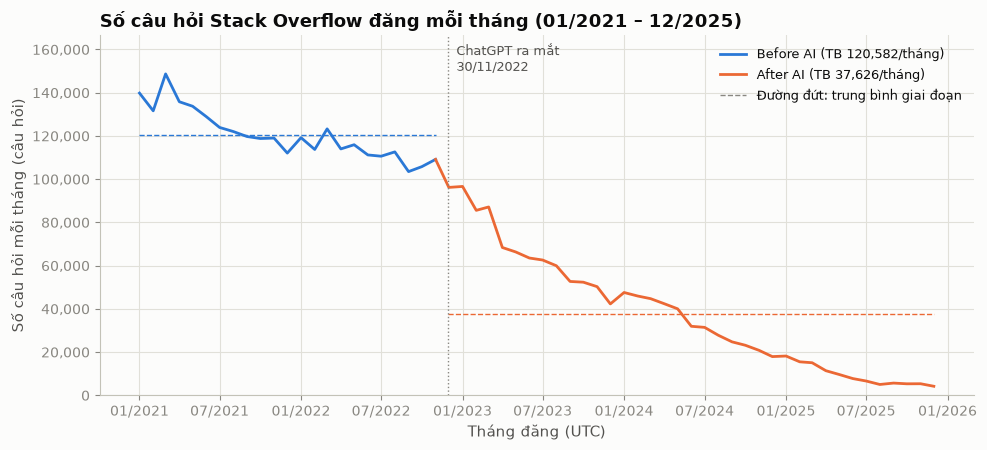

**Kết quả.** Sau khi AI phổ biến, số lượng câu hỏi trên Stack Overflow giảm **68.8%** (trung bình mỗi tháng từ 120,582 xuống 37,626) trong phạm vi dữ liệu được phân tích.
- Xu hướng giảm đã có từ trước: từ 01/2021 đến 11/2022, câu hỏi mỗi tháng đã giảm 21.9%. Sau ChatGPT, từ 11/2022 đến 12/2025 giảm 96.2%.
- Kết quả cho thấy có sự thay đổi đáng kể về hoạt động hỏi đáp trong giai đoạn sau khi AI phổ biến; dữ liệu này chưa đủ để nói AI là nguyên nhân duy nhất.

In [10]:
fig, ax = plt.subplots(figsize=(10, 4.6))
plot_monthly(ax, q, "Số câu hỏi Stack Overflow đăng mỗi tháng (01/2021 – 12/2025)", "Số câu hỏi mỗi tháng (câu hỏi)",
             f"Before AI (TB {q_before:,.0f}/tháng)", f"After AI (TB {q_after:,.0f}/tháng)", q_before, q_after)
plt.tight_layout(); plt.show()

pre_trend = pct_change(q.iloc[0], q.loc[pd.Timestamp("2022-11-01")])
post_trend = pct_change(q.loc[pd.Timestamp("2022-11-01")], q.iloc[-1])
show(f"""**Kết quả.** Sau khi AI phổ biến, số lượng câu hỏi trên Stack Overflow giảm **{abs(q_change):.1f}%** \
(trung bình mỗi tháng từ {q_before:,.0f} xuống {q_after:,.0f}) trong phạm vi dữ liệu được phân tích.
- Xu hướng giảm đã có từ trước: từ 01/2021 đến 11/2022, câu hỏi mỗi tháng đã giảm {abs(pre_trend):.1f}%. Sau ChatGPT, từ 11/2022 đến 12/2025 giảm {abs(post_trend):.1f}%.
- Kết quả cho thấy có sự thay đổi đáng kể về hoạt động hỏi đáp trong giai đoạn sau khi AI phổ biến; dữ liệu này chưa đủ để nói AI là nguyên nhân duy nhất.""")

## 06. Số câu trả lời

**Câu hỏi:** Hoạt động trả lời trên Stack Overflow thay đổi như thế nào sau khi AI phổ biến?
**Dữ liệu:** số câu trả lời đăng mỗi tháng (đếm chính xác, gồm cả trả lời cho câu hỏi cũ). **Tính toán:** giống phân tích 1.

In [11]:
a = totals.set_index(pd.to_datetime(totals["Month"] + "-01"))["Answers"]

ans_year = totals.assign(Năm=totals["Month"].str[:4]).groupby("Năm")[["Answers"]].sum()
ans_year["Thay đổi so với năm trước (%)"] = ans_year["Answers"].pct_change().mul(100).round(1)
display(ans_year.rename(columns={"Answers": "Answers (cả năm)"}).map(fmt_cell))

a_before = totals.loc[totals["Period"] == "Before AI", "Answers"].mean()
a_after = totals.loc[totals["Period"] == "After AI", "Answers"].mean()
a_change = pct_change(a_before, a_after)
print(f"Trung bình mỗi tháng: Before AI = {a_before:,.0f} | After AI = {a_after:,.0f} | Thay đổi = {a_change:+.1f}%")

,Answers (cả năm),Thay đổi so với năm trước (%)
Năm,,
2021,"1,986,284",–
2022,"1,718,090",-13.5
2023,"1,026,295",-40.3
2024,"566,993",-44.8
2025,"188,478",-66.8


Trung bình mỗi tháng: Before AI = 155,680 | After AI = 51,500 | Thay đổi = -66.9%


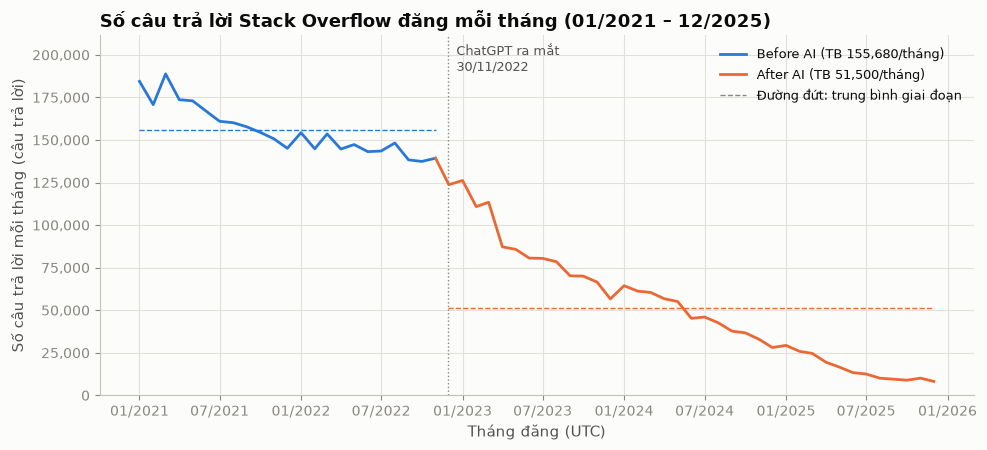

**Kết quả.** Sau khi AI phổ biến, số câu trả lời trên Stack Overflow giảm **66.9%** (trung bình mỗi tháng từ 155,680 xuống 51,500) trong phạm vi dữ liệu được phân tích.
- Trước AI, câu trả lời mỗi tháng đã giảm 24.5% (01/2021 → 11/2022); sau ChatGPT giảm 94.1% (11/2022 → 12/2025).
- Mức giảm của Answers (66.9%) nhỏ hơn mức giảm của Questions (68.8%); tỷ số Answers/Question được xem ở mục 07.

In [12]:
fig, ax = plt.subplots(figsize=(10, 4.6))
plot_monthly(ax, a, "Số câu trả lời Stack Overflow đăng mỗi tháng (01/2021 – 12/2025)", "Số câu trả lời mỗi tháng (câu trả lời)",
             f"Before AI (TB {a_before:,.0f}/tháng)", f"After AI (TB {a_after:,.0f}/tháng)", a_before, a_after)
plt.tight_layout(); plt.show()

pre_trend_a = pct_change(a.iloc[0], a.loc[pd.Timestamp("2022-11-01")])
post_trend_a = pct_change(a.loc[pd.Timestamp("2022-11-01")], a.iloc[-1])
show(f"""**Kết quả.** Sau khi AI phổ biến, số câu trả lời trên Stack Overflow giảm **{abs(a_change):.1f}%** \
(trung bình mỗi tháng từ {a_before:,.0f} xuống {a_after:,.0f}) trong phạm vi dữ liệu được phân tích.
- Trước AI, câu trả lời mỗi tháng đã giảm {abs(pre_trend_a):.1f}% (01/2021 → 11/2022); sau ChatGPT giảm {abs(post_trend_a):.1f}% (11/2022 → 12/2025).
- Mức giảm của Answers ({abs(a_change):.1f}%) {"nhỏ hơn" if abs(a_change) < abs(q_change) else "lớn hơn"} mức giảm của Questions ({abs(q_change):.1f}%); tỷ số Answers/Question được xem ở mục 07.""")

## 07. Số câu trả lời trên mỗi câu hỏi

**Câu hỏi:** Một câu hỏi trên Stack Overflow hiện nhận được nhiều hay ít câu trả lời hơn trước?
**Công thức:** `Average Answers per Question = Total Answers / Total Questions`. Có 2 cách tính (dữ liệu cho phép cả hai):
- **Cách 1 (chính) – theo từng câu hỏi:** trung bình `AnswerCount` của các câu hỏi đăng trong giai đoạn (= tổng câu trả lời mà các câu hỏi đó nhận được ÷ số câu hỏi). Đây là cách trả lời trực tiếp câu hỏi trên. *(Ước lượng từ mẫu.)*
- **Cách 2 (đối chiếu) – theo tổng tháng:** Answers đăng trong tháng ÷ Questions đăng trong tháng. Câu trả lời đăng trong tháng có thể là trả lời cho câu hỏi **cũ**. *(Đếm chính xác.)*

In [13]:
apq = {}
for p in PERIODS:
    g = df[df["Period"] == p]
    apq[p] = (wmean(g["AnswerCount"], g["Weight"]), wmargin(g["AnswerCount"].astype(float), g["Weight"]))
apq_change = pct_change(apq["Before AI"][0], apq["After AI"][0])

ratio = totals.groupby("Period")[["Questions", "Answers"]].sum().loc[PERIODS]
ratio["Answers / Question"] = ratio["Answers"] / ratio["Questions"]
ratio_change = pct_change(*ratio["Answers / Question"])

display(pd.DataFrame({
    "Cách 1: AnswerCount TB / câu hỏi (mẫu)": [f"{apq[p][0]:.3f} ± {apq[p][1]:.3f}" for p in PERIODS],
    "Cách 2: Answers đăng / Questions đăng (chính xác)": [f"{ratio.loc[p, 'Answers / Question']:.3f}" for p in PERIODS]},
    index=PERIODS))
print(f"Thay đổi: Cách 1 = {apq_change:+.1f}% | Cách 2 = {ratio_change:+.1f}%")

,Cách 1: AnswerCount TB / câu hỏi (mẫu),Cách 2: Answers đăng / Questions đăng (chính xác)
Before AI,1.162 ± 0.040,1.291
After AI,1.003 ± 0.031,1.369


Thay đổi: Cách 1 = -13.7% | Cách 2 = +6.0%


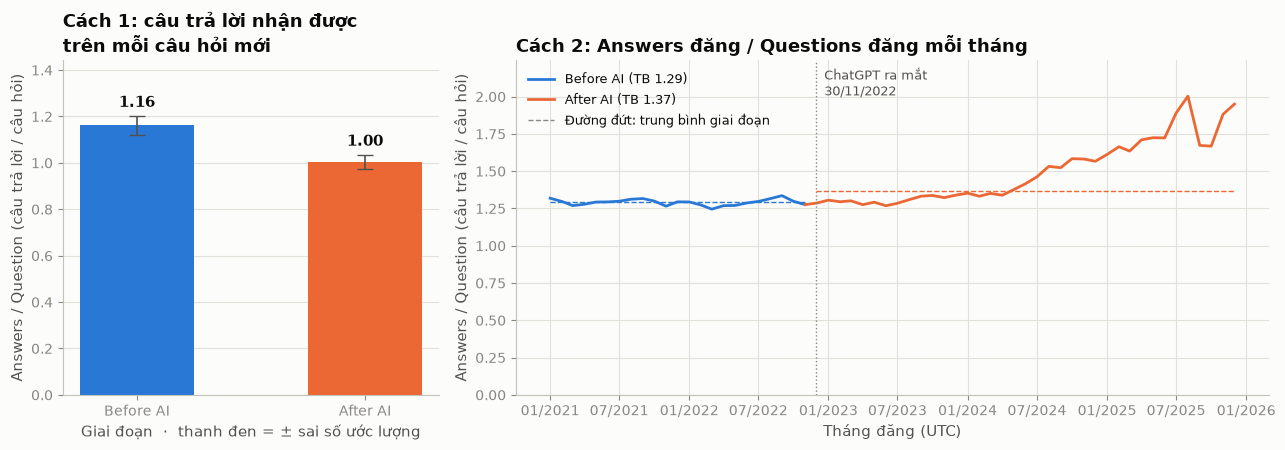

**Kết quả.** Theo Cách 1, mỗi câu hỏi mới nhận trung bình **1.16 → 1.00 câu trả lời** (-13.7%) sau khi AI phổ biến; khác biệt lớn hơn sai số của mẫu.
- Theo Cách 2, tỷ số Answers đăng / Questions đăng lại **tăng** từ 1.29 lên 1.37 (+6.0%).
- Hai kết quả không mâu thuẫn: Cách 2 tính cả câu trả lời cho câu hỏi **cũ**, và số câu hỏi mới giảm nhiều hơn số câu trả lời (mục 05 – 06). Còn một câu hỏi **mới** thì nhận được ít câu trả lời hơn trước (Cách 1).

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={"width_ratios": [1, 2]})
plot_bars(ax1, [apq[p][0] for p in PERIODS], [apq[p][1] for p in PERIODS],
          "Cách 1: câu trả lời nhận được\ntrên mỗi câu hỏi mới", "Answers / Question (câu trả lời / câu hỏi)", lambda v: f"{v:.2f}")
monthly_ratio = (totals["Answers"] / totals["Questions"]).set_axis(q.index)
plot_monthly(ax2, monthly_ratio, "Cách 2: Answers đăng / Questions đăng mỗi tháng", "Answers / Question (câu trả lời / câu hỏi)",
             f"Before AI (TB {ratio.loc['Before AI', 'Answers / Question']:.2f})", f"After AI (TB {ratio.loc['After AI', 'Answers / Question']:.2f})",
             ratio.loc["Before AI", "Answers / Question"], ratio.loc["After AI", "Answers / Question"],
             int_axis=False, legend_loc="upper left")
plt.tight_layout(); plt.show()

real = beyond_error(apq["Before AI"][0], apq["After AI"][0], apq["Before AI"][1], apq["After AI"][1])
if apq_change < 0 < ratio_change and abs(q_change) > abs(a_change):
    explain = ("Hai kết quả không mâu thuẫn: Cách 2 tính cả câu trả lời cho câu hỏi **cũ**, và số câu hỏi mới giảm nhiều hơn số câu trả lời (mục 05 – 06). "
               "Còn một câu hỏi **mới** thì nhận được ít câu trả lời hơn trước (Cách 1).")
else:
    explain = "Hai cách tính đo hai điều khác nhau (Cách 2 gồm cả câu trả lời cho câu hỏi cũ), nên kết quả có thể khác nhau."
show(f"""**Kết quả.** Theo Cách 1, mỗi câu hỏi mới nhận trung bình **{apq['Before AI'][0]:.2f} → {apq['After AI'][0]:.2f} câu trả lời** \
({apq_change:+.1f}%) sau khi AI phổ biến; khác biệt {"lớn hơn" if real else "nhỏ hơn"} sai số của mẫu.
- Theo Cách 2, tỷ số Answers đăng / Questions đăng lại **{"tăng" if ratio_change > 0 else "giảm"}** từ {ratio.loc['Before AI', 'Answers / Question']:.2f} lên {ratio.loc['After AI', 'Answers / Question']:.2f} ({ratio_change:+.1f}%).
- {explain}""")

## 08. Mức độ tương tác

**Câu hỏi:** Mức độ tương tác của cộng đồng đối với các câu hỏi có thay đổi sau khi AI phổ biến không?
**Chỉ số:** `Score` (số vote ròng của câu hỏi: vote lên trừ vote xuống) – trung bình, trung vị (giá trị nằm giữa, không bị vài câu hỏi điểm rất cao kéo lệch) và tỷ lệ câu hỏi có Score ≥ 1 (bổ sung vì trung vị đều bằng 0).
**ViewCount:** số lượt xem tích luỹ phụ thuộc vào thời gian câu hỏi tồn tại, nên được kiểm tra riêng trước khi quyết định có dùng để so sánh hai giai đoạn hay không.

In [15]:
by_year = (df.assign(Năm=df["CreationDate"].dt.year)
             .groupby("Năm").agg(Câu_hỏi_mẫu=("Id", "count"), Views_TB=("ViewCount", "mean"),
                                  Views_trung_vị=("ViewCount", "median"), Score_TB=("Score", "mean")).round(1)
             .rename(columns=lambda c: c.replace("_", " ")))
display(by_year)
v_first, v_last = by_year["Views trung vị"].iloc[0], by_year["Views trung vị"].iloc[-1]
print(f"Trung vị ViewCount: câu hỏi năm {by_year.index[0]} = {v_first:,.0f} lượt, năm {by_year.index[-1]} = {v_last:,.0f} lượt.")
print("-> Khác biệt chủ yếu do TUỔI của câu hỏi, không phải do sự quan tâm của cộng đồng -> BỎ ViewCount, chỉ dùng Score.")

,Câu hỏi mẫu,Views TB,Views trung vị,Score TB
Năm,,,,
2021,1200,1602.1,441.5,1.1
2022,1200,1364.8,325.0,0.6
2023,1200,675.2,216.0,0.5
2024,1200,387.0,136.0,0.5
2025,1200,244.6,133.5,0.8


Trung vị ViewCount: câu hỏi năm 2021 = 442 lượt, năm 2025 = 134 lượt.
-> Khác biệt chủ yếu do TUỔI của câu hỏi, không phải do sự quan tâm của cộng đồng -> BỎ ViewCount, chỉ dùng Score.


In [16]:
eng = {}
for p in PERIODS:
    g = df[df["Period"] == p]
    s, pos = g["Score"].astype(float), (g["Score"] >= 1).astype(float)
    eng[p] = {"mean": wmean(s, g["Weight"]), "mean_m": wmargin(s, g["Weight"]), "median": wmedian(g["Score"], g["Weight"]),
              "pos": wmean(pos, g["Weight"]) * 100, "pos_m": wmargin(pos, g["Weight"]) * 100}

mean_change = pct_change(eng["Before AI"]["mean"], eng["After AI"]["mean"])
pos_change = pct_change(eng["Before AI"]["pos"], eng["After AI"]["pos"])
display(pd.DataFrame({
    "Score trung bình": [f"{eng[p]['mean']:.2f} ± {eng[p]['mean_m']:.2f}" for p in PERIODS],
    "Score trung vị": [f"{eng[p]['median']:.0f}" for p in PERIODS],
    "% câu hỏi có Score >= 1": [f"{eng[p]['pos']:.1f}% ± {eng[p]['pos_m']:.1f}" for p in PERIODS]}, index=PERIODS))
print(f"Thay đổi: Score trung bình {mean_change:+.1f}% | Score trung vị: không đổi (đều bằng {eng['Before AI']['median']:.0f}) | Tỷ lệ Score >= 1: {pos_change:+.1f}%")

,Score trung bình,Score trung vị,% câu hỏi có Score >= 1
Before AI,0.92 ± 0.21,0,41.2% ± 2.0
After AI,0.51 ± 0.05,0,38.2% ± 1.9


Thay đổi: Score trung bình -44.2% | Score trung vị: không đổi (đều bằng 0) | Tỷ lệ Score >= 1: -7.3%


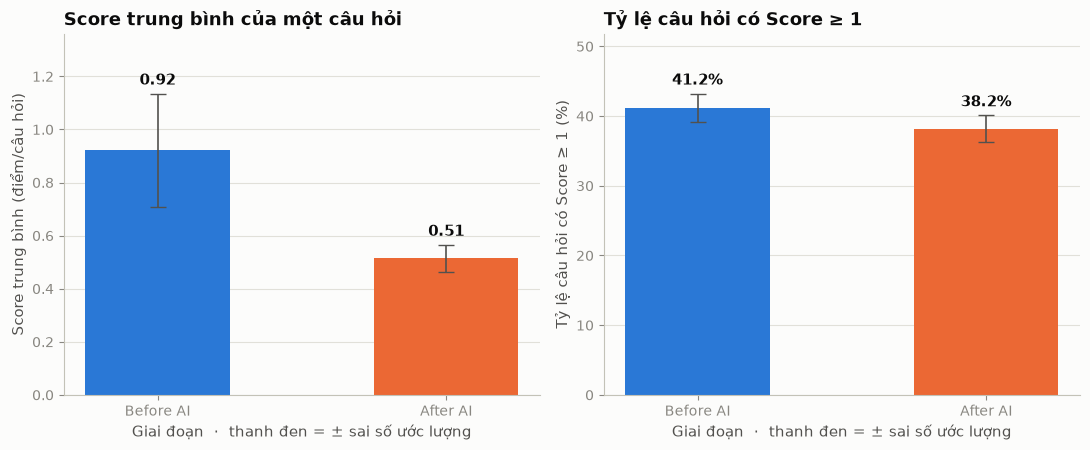

**Kết quả.** Sau khi AI phổ biến, Score trung bình của một câu hỏi thay đổi **-44.2%** (0.92 → 0.51); khác biệt lớn hơn sai số của mẫu.
- Tỷ lệ câu hỏi có Score ≥ 1 đổi từ 41.2% xuống 38.2% (-7.3%); khác biệt lớn hơn sai số. Trung vị Score đều bằng 0: ít nhất một nửa số câu hỏi ở cả hai giai đoạn có Score ≤ 0.
- Cần đọc thận trọng: Score cũng tích luỹ theo thời gian, nên câu hỏi Before (cũ hơn) có lợi thế hơn.

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.6))
plot_bars(ax1, [eng[p]["mean"] for p in PERIODS], [eng[p]["mean_m"] for p in PERIODS],
          "Score trung bình của một câu hỏi", "Score trung bình (điểm/câu hỏi)", lambda v: f"{v:.2f}")
plot_bars(ax2, [eng[p]["pos"] for p in PERIODS], [eng[p]["pos_m"] for p in PERIODS],
          "Tỷ lệ câu hỏi có Score ≥ 1", "Tỷ lệ câu hỏi có Score ≥ 1 (%)", lambda v: f"{v:.1f}%")
plt.tight_layout(); plt.show()

med_b, med_a = eng["Before AI"]["median"], eng["After AI"]["median"]
med_txt = ("Trung vị Score đều bằng 0: ít nhất một nửa số câu hỏi ở cả hai giai đoạn có Score ≤ 0." if med_b == med_a == 0
           else f"Trung vị Score: {med_b:.0f} (Before) và {med_a:.0f} (After).")
real_mean = beyond_error(eng["Before AI"]["mean"], eng["After AI"]["mean"], eng["Before AI"]["mean_m"], eng["After AI"]["mean_m"])
real_pos = beyond_error(eng["Before AI"]["pos"], eng["After AI"]["pos"], eng["Before AI"]["pos_m"], eng["After AI"]["pos_m"])
show(f"""**Kết quả.** Sau khi AI phổ biến, Score trung bình của một câu hỏi thay đổi **{mean_change:+.1f}%** \
({eng['Before AI']['mean']:.2f} → {eng['After AI']['mean']:.2f}); khác biệt {"lớn hơn" if real_mean else "nhỏ hơn"} sai số của mẫu.
- Tỷ lệ câu hỏi có Score ≥ 1 đổi từ {eng['Before AI']['pos']:.1f}% xuống {eng['After AI']['pos']:.1f}% ({pos_change:+.1f}%); khác biệt {"lớn hơn" if real_pos else "nhỏ hơn"} sai số. \
{med_txt}
- Cần đọc thận trọng: Score cũng tích luỹ theo thời gian, nên câu hỏi Before (cũ hơn) có lợi thế hơn.""")

## 09. Câu trả lời được chấp nhận

**Câu hỏi:** Tỷ lệ câu hỏi nhận được câu trả lời được chấp nhận có thay đổi sau khi AI phổ biến không?
**Dữ liệu:** `AcceptedAnswerId` (có giá trị = người hỏi đã chọn 1 câu trả lời đúng). Dữ liệu đủ để tính.
**Công thức:** `Accepted Answer Rate = Số câu hỏi có Accepted Answer / Tổng số câu hỏi × 100`.

In [18]:
acc = {}
for p in PERIODS:
    g = df[df["Period"] == p]
    x = g["HasAccepted"].astype(float)
    acc[p] = (wmean(x, g["Weight"]) * 100, wmargin(x, g["Weight"]) * 100)

acc_change = pct_change(acc["Before AI"][0], acc["After AI"][0])
acc_pp = acc["After AI"][0] - acc["Before AI"][0]
display(pd.DataFrame({"Accepted Answer Rate": [f"{acc[p][0]:.1f}% ± {acc[p][1]:.1f}" for p in PERIODS]}, index=PERIODS))
print(f"Thay đổi = {acc_change:+.1f}% (tức {acc_pp:+.1f} điểm phần trăm)")

,Accepted Answer Rate
Before AI,43.4% ± 2.0
After AI,37.0% ± 1.9


Thay đổi = -14.7% (tức -6.4 điểm phần trăm)


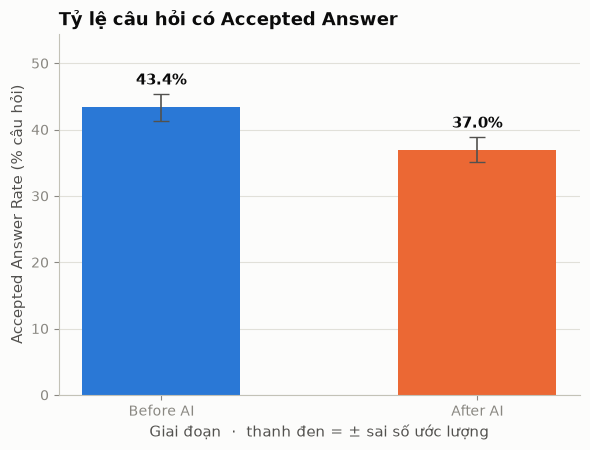

**Kết quả.** Sau khi AI phổ biến, tỷ lệ câu hỏi có Accepted Answer thay đổi từ **43.4% xuống 37.0%** (-14.7%, tức -6.4 điểm phần trăm); khác biệt lớn hơn sai số của mẫu, trong phạm vi dữ liệu được phân tích.

In [19]:
fig, ax = plt.subplots(figsize=(6, 4.6))
plot_bars(ax, [acc[p][0] for p in PERIODS], [acc[p][1] for p in PERIODS],
          "Tỷ lệ câu hỏi có Accepted Answer", "Accepted Answer Rate (% câu hỏi)", lambda v: f"{v:.1f}%")
plt.tight_layout(); plt.show()

real_acc = beyond_error(acc["Before AI"][0], acc["After AI"][0], acc["Before AI"][1], acc["After AI"][1])
show(f"""**Kết quả.** Sau khi AI phổ biến, tỷ lệ câu hỏi có Accepted Answer thay đổi từ **{acc['Before AI'][0]:.1f}% xuống {acc['After AI'][0]:.1f}%** \
({acc_change:+.1f}%, tức {acc_pp:+.1f} điểm phần trăm); khác biệt {"lớn hơn" if real_acc else "nhỏ hơn"} sai số của mẫu, trong phạm vi dữ liệu được phân tích.""")

## 10. Tag lập trình

**Câu hỏi:** Các chủ đề/công nghệ lập trình được hỏi trên Stack Overflow có thay đổi sau khi AI phổ biến không?
**Dữ liệu:** số câu hỏi theo tag (đếm chính xác). Ứng viên là các công nghệ (ngôn ngữ, framework, thư viện, CSDL) chiếm ≥ 1.5% số câu hỏi ở ít nhất một giai đoạn – ngưỡng thấp hơn nhiều so với hạng 10 (~2.7%) nên top 10 không bỏ sót tag nào. Các tag chung chung như `arrays`, `json` không tính.
**Tính toán:** *câu hỏi trung bình mỗi tháng* (để so sánh công bằng) và *tỷ trọng* = số câu hỏi có tag ÷ tổng câu hỏi của giai đoạn. Một câu hỏi có nhiều tag nên tỷ trọng các tag cộng lại có thể vượt 100%. Vì tổng số câu hỏi giảm rất mạnh, cách xác định tag "tăng/giảm" là so **tỷ trọng** (Δ = tỷ trọng After − tỷ trọng Before): tỷ trọng tăng nghĩa là tag đó giảm *ít hơn* mức chung. Phần này xét cả 25 công nghệ ứng viên.

In [20]:
tc = tag_counts[tag_counts["Group"] == "Programming"].copy()
tc["Period"] = tc["Period"] + " AI"
tc["PerMonth"] = tc["Questions"] / tc["Months"]
tc["Share"] = tc["Questions"] / tc["Period"].map(totals.groupby("Period")["Questions"].sum()) * 100
pm, sh = tc.pivot(index="Tag", columns="Period", values="PerMonth"), tc.pivot(index="Tag", columns="Period", values="Share")

top_before = pm["Before AI"].nlargest(10).index.tolist()
top_after = pm["After AI"].nlargest(10).index.tolist()

tags = pd.DataFrame({
    "TB/tháng Before": pm["Before AI"], "TB/tháng After": pm["After AI"], "% thay đổi": pct_change(pm["Before AI"], pm["After AI"]),
    "Tỷ trọng Before (%)": sh["Before AI"], "Tỷ trọng After (%)": sh["After AI"], "Δ tỷ trọng (điểm %)": sh["After AI"] - sh["Before AI"],
    "Hạng Before": pm["Before AI"].rank(ascending=False).astype(int), "Hạng After": pm["After AI"].rank(ascending=False).astype(int)
}).sort_values("TB/tháng Before", ascending=False)
union = [t for t in tags.index if t in set(top_before) | set(top_after)]

print("Top 10 Before AI:", top_before)
print("Top 10 After AI :", top_after)
print("Vào top 10 sau AI:", [t for t in top_after if t not in top_before] or "không có", "| Rời top 10:", [t for t in top_before if t not in top_after] or "không có")
print(f"Toàn bộ câu hỏi (mục 05) thay đổi {q_change:+.1f}% -> tag có tỷ trọng tăng nghĩa là giảm ÍT HƠN mức chung.")
table = tags.round(1)
table["Δ tỷ trọng (điểm %)"] += 0.0
display(table)

Top 10 Before AI: ['python', 'javascript', 'reactjs', 'java', 'c#', 'html', 'r', 'android', 'flutter', 'node.js']
Top 10 After AI : ['python', 'javascript', 'c#', 'java', 'reactjs', 'html', 'android', 'r', 'flutter', 'c++']
Vào top 10 sau AI: ['c++'] | Rời top 10: ['node.js']
Toàn bộ câu hỏi (mục 05) thay đổi -68.8% -> tag có tỷ trọng tăng nghĩa là giảm ÍT HƠN mức chung.


,TB/tháng Before,TB/tháng After,% thay đổi,Tỷ trọng Before (%),Tỷ trọng After (%),Δ tỷ trọng (điểm %),Hạng Before,Hạng After
Tag,,,,,,,,
python,19899.4,5192.5,-73.9,16.5,13.8,-2.7,1,1
javascript,13799.8,3176.8,-77.0,11.4,8.4,-3.0,2,2
reactjs,6732.0,1794.5,-73.3,5.6,4.8,-0.8,3,5
java,6527.4,1826.5,-72.0,5.4,4.9,-0.6,4,4
c#,5382.3,1901.1,-64.7,4.5,5.1,0.6,5,3
html,5174.0,1286.9,-75.1,4.3,3.4,-0.9,6,6
r,4096.8,1235.6,-69.8,3.4,3.3,-0.1,7,8
android,4046.0,1259.8,-68.9,3.4,3.3,0.0,8,7
flutter,3762.0,1086.1,-71.1,3.1,2.9,-0.2,9,9


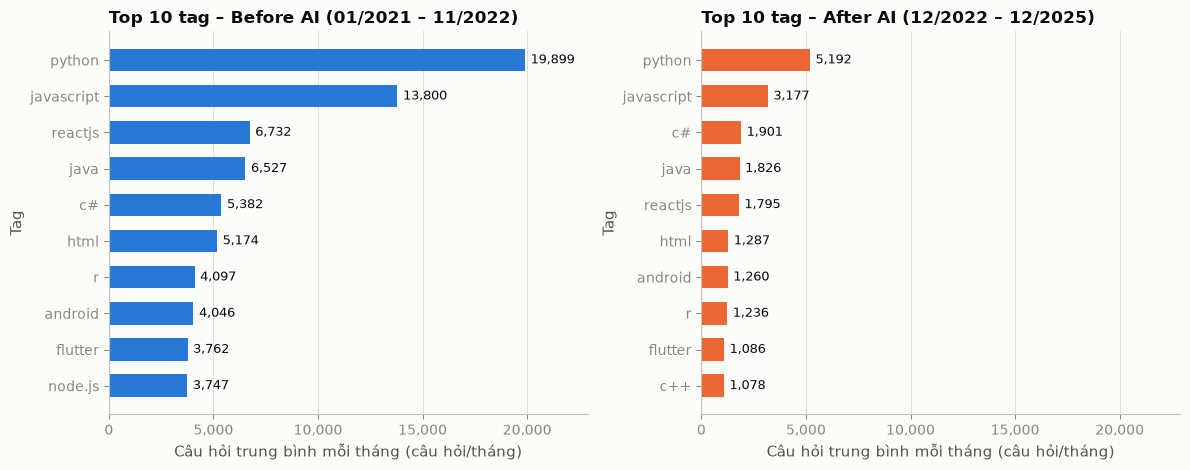

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharex=True)
for ax, period, top, color, rng in [(axes[0], "Before AI", top_before, C_BEFORE, "01/2021 – 11/2022"),
                                     (axes[1], "After AI", top_after, C_AFTER, "12/2022 – 12/2025")]:
    vals = pm.loc[top, period]
    bars = ax.barh(top[::-1], vals[::-1], color=color, height=0.62)
    for b, v in zip(bars, vals[::-1]):
        ax.annotate(f"{v:,.0f}", (v, b.get_y() + b.get_height() / 2), xytext=(4, 0), textcoords="offset points", va="center", fontsize=9.5)
    ax.set_title(f"Top 10 tag – {period} ({rng})", fontsize=12); ax.set_xlabel("Câu hỏi trung bình mỗi tháng (câu hỏi/tháng)")
    ax.set_ylabel("Tag"); ax.grid(axis="y", visible=False); ax.xaxis.set_major_formatter(FuncFormatter(thousands))
axes[0].set_xlim(0, pm["Before AI"].max() * 1.15)
plt.tight_layout(); plt.show()

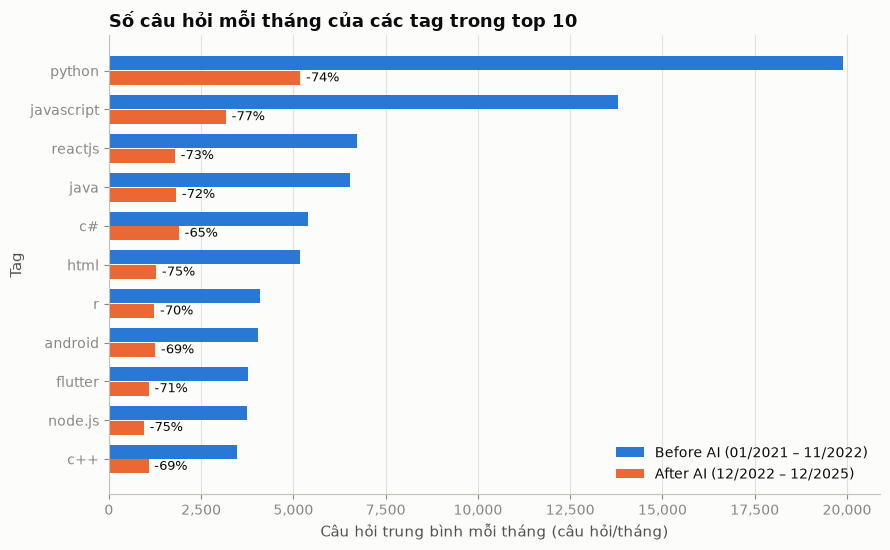

In [22]:
order = union[::-1]
y = np.arange(len(order))
fig, ax = plt.subplots(figsize=(9, 5.6))
ax.barh(y + 0.19, pm.loc[order, "Before AI"], height=0.36, color=C_BEFORE, label="Before AI (01/2021 – 11/2022)")
ax.barh(y - 0.19, pm.loc[order, "After AI"], height=0.36, color=C_AFTER, label="After AI (12/2022 – 12/2025)")
for i, t in zip(y, order):
    ax.annotate(f"{tags.loc[t, '% thay đổi']:+.0f}%", (pm.loc[t, "After AI"], i - 0.19), xytext=(4, 0), textcoords="offset points", va="center", fontsize=9.5)
ax.set_yticks(y, order); ax.set_title("Số câu hỏi mỗi tháng của các tag trong top 10")
ax.set_xlabel("Câu hỏi trung bình mỗi tháng (câu hỏi/tháng)"); ax.set_ylabel("Tag")
ax.xaxis.set_major_formatter(FuncFormatter(thousands)); ax.grid(axis="y", visible=False); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

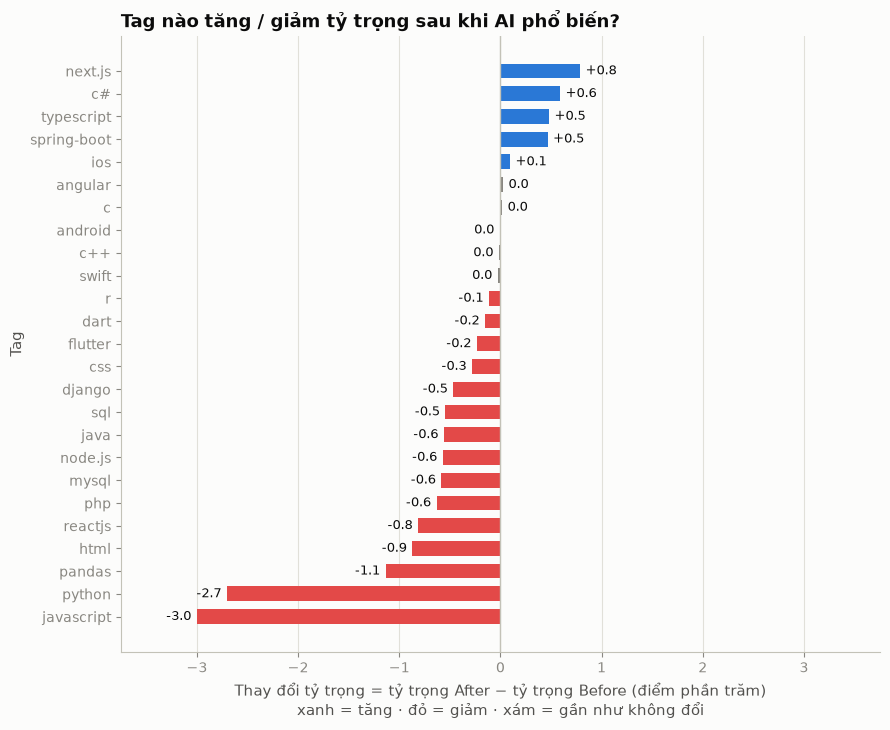

In [23]:
delta = tags["Δ tỷ trọng (điểm %)"].sort_values()
fig, ax = plt.subplots(figsize=(9, 7.4))
FLAT = 0.05
bars = ax.barh(delta.index, delta.values, height=0.65,
               color=[MUTED if abs(d) < FLAT else (C_UP if d > 0 else C_DOWN) for d in delta])
for b, d in zip(bars, delta):
    label = "0.0" if abs(d) < FLAT else f"{d:+.1f}"
    ax.annotate(label, (d, b.get_y() + b.get_height() / 2), xytext=(4 if d >= 0 else -4, 0), textcoords="offset points",
                ha="left" if d >= 0 else "right", va="center", fontsize=9.5)
ax.axvline(0, color="#c3c2b7", lw=1)
lim = delta.abs().max() * 1.25; ax.set_xlim(-lim, lim)
ax.set_title("Tag nào tăng / giảm tỷ trọng sau khi AI phổ biến?")
ax.set_xlabel("Thay đổi tỷ trọng = tỷ trọng After − tỷ trọng Before (điểm phần trăm)\nxanh = tăng · đỏ = giảm · xám = gần như không đổi")
ax.set_ylabel("Tag"); ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

,Tổng Before,Tổng After,TB/tháng Before,TB/tháng After
Tag,,,,
openai-api,142,"2,364",6.2,63.9
langchain,1,"1,947",0.0,52.6
huggingface-transformers,"1,274","1,556",55.4,42.1
large-language-model,3,"1,515",0.1,40.9
chatgpt-api,0,500,0.0,13.5
llama-index,0,317,0.0,8.6


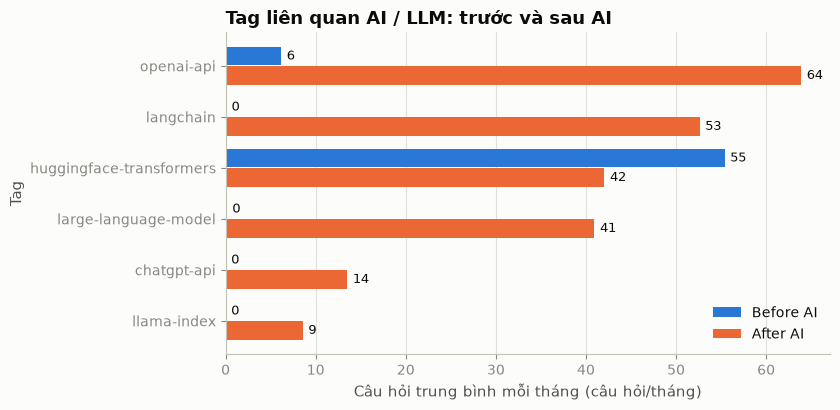

**Kết quả.** Trong phạm vi dữ liệu được phân tích, **cả 25 công nghệ đều có ít câu hỏi hơn** (cùng với mức giảm chung -68.8%), nhưng mức giảm không đều nên tỷ trọng và thứ hạng thay đổi.
- Đứng đầu Before: `python`, `javascript`; đứng đầu After: `python`, `javascript`. Vào top 10 sau AI: `c++`; rời top 10: `node.js`. Đổi hạng nhiều nhất: `c++` (14 → 10), `node.js` (10 → 13), `c#` (5 → 3), `reactjs` (3 → 5).
- Tag **tăng tỷ trọng** (5/25 công nghệ), nhiều nhất: `next.js` (+0.8), `c#` (+0.6), `typescript` (+0.5), `spring-boot` (+0.5). Tag **giảm tỷ trọng** (15/25), nhiều nhất: `javascript` (-3.0), `python` (-2.7), `pandas` (-1.1); còn lại 5 tag gần như không đổi (đơn vị: điểm %; đếm chính xác nên không có sai số lấy mẫu).
- Tag liên quan AI/LLM **xuất hiện nhiều hơn hẳn** sau AI: `openai-api`, `langchain`, `large-language-model`, `chatgpt-api`, `llama-index` (trung bình mỗi tháng tăng gấp ≥ 5 lần).

In [24]:
ai = tag_counts[tag_counts["Group"] == "AI/LLM"].copy()
ai["Period"] = ai["Period"] + " AI"
ai_tab = ai.pivot(index="Tag", columns="Period", values="Questions")[PERIODS]
ai_tab.columns = ["Tổng Before", "Tổng After"]
n_months = totals.groupby("Period")["Month"].count()
ai_tab["TB/tháng Before"] = ai_tab["Tổng Before"] / n_months["Before AI"]
ai_tab["TB/tháng After"] = ai_tab["Tổng After"] / n_months["After AI"]
ai_tab = ai_tab.sort_values("TB/tháng After", ascending=False)
display(ai_tab.map(fmt_cell))

fig, ax = plt.subplots(figsize=(8.5, 4.2))
yy = np.arange(len(ai_tab))[::-1]
ax.barh(yy + 0.19, ai_tab["TB/tháng Before"], height=0.36, color=C_BEFORE, label="Before AI")
ax.barh(yy - 0.19, ai_tab["TB/tháng After"], height=0.36, color=C_AFTER, label="After AI")
for i, (_, r) in zip(yy, ai_tab.iterrows()):
    ax.annotate(f"{r['TB/tháng After']:.0f}", (r["TB/tháng After"], i - 0.19), xytext=(4, 0), textcoords="offset points", va="center", fontsize=9.5)
    ax.annotate(f"{r['TB/tháng Before']:.0f}", (r["TB/tháng Before"], i + 0.19), xytext=(4, 0), textcoords="offset points", va="center", fontsize=9.5)
ax.set_yticks(yy, ai_tab.index); ax.set_title("Tag liên quan AI / LLM: trước và sau AI"); ax.set_xlabel("Câu hỏi trung bình mỗi tháng (câu hỏi/tháng)")
ax.set_ylabel("Tag"); ax.grid(axis="y", visible=False); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

gain = delta[delta >= FLAT].sort_values(ascending=False)
loss = delta[delta <= -FLAT].sort_values()
rank_move = (tags.loc[union, "Hạng Before"] - tags.loc[union, "Hạng After"])
moves = rank_move[rank_move.abs() >= 2].sort_values(key=abs, ascending=False)
new_tags = ai_tab[(ai_tab["TB/tháng After"] > 5 * ai_tab["TB/tháng Before"]) & (ai_tab["TB/tháng After"] > 5)].index.tolist()
all_down = bool((tags["% thay đổi"] < 0).all())
show(f"""**Kết quả.** Trong phạm vi dữ liệu được phân tích, **{"cả 25 công nghệ đều có ít câu hỏi hơn" if all_down else "hầu hết các công nghệ có ít câu hỏi hơn"}** \
(cùng với mức giảm chung {q_change:+.1f}%), nhưng mức giảm không đều nên tỷ trọng và thứ hạng thay đổi.
- Đứng đầu Before: `{top_before[0]}`, `{top_before[1]}`; đứng đầu After: `{top_after[0]}`, `{top_after[1]}`. \
Vào top 10 sau AI: {", ".join(f"`{t}`" for t in top_after if t not in top_before) or "không có"}; rời top 10: {", ".join(f"`{t}`" for t in top_before if t not in top_after) or "không có"}. \
Đổi hạng nhiều nhất: {", ".join(f"`{t}` ({tags.loc[t, 'Hạng Before']} → {tags.loc[t, 'Hạng After']})" for t in moves.index) or "không có"}.
- Tag **tăng tỷ trọng** ({len(gain)}/{len(delta)} công nghệ), nhiều nhất: {", ".join(f"`{t}` ({v:+.1f})" for t, v in gain.head(4).items())}. \
Tag **giảm tỷ trọng** ({len(loss)}/{len(delta)}), nhiều nhất: {", ".join(f"`{t}` ({v:+.1f})" for t, v in loss.head(3).items())}; còn lại {len(delta) - len(gain) - len(loss)} tag gần như không đổi \
(đơn vị: điểm %; đếm chính xác nên không có sai số lấy mẫu).
- Tag liên quan AI/LLM **xuất hiện nhiều hơn hẳn** sau AI: {", ".join(f"`{t}`" for t in new_tags)} (trung bình mỗi tháng tăng gấp ≥ 5 lần).""")

## 11. Tổng hợp kết quả
Bảng tổng hợp. Cột "Độ chính xác" cho biết số liệu là **đếm chính xác** hay **ước lượng từ mẫu** (kèm sai số ±). "Vượt sai số?" = khác biệt Before/After có lớn hơn sai số của mẫu hay không.

## 12. Kết luận
Từ dữ liệu thu thập qua API chính thức của Stack Exchange (60 tháng, 01/2021 – 12/2025), notebook so sánh hoạt động hỏi đáp lập trình trên Stack Overflow giữa **Before AI** (01/2021 – 11/2022, 23 tháng) và **After AI** (12/2022 – 12/2025, 37 tháng).

- **Questions:** số câu hỏi trung bình mỗi tháng giảm **68.8%** (120,582 → 37,626).
- **Answers:** số câu trả lời trung bình mỗi tháng giảm **66.9%** (155,680 → 51,500).
- **Answers/Question:** một câu hỏi mới nhận trung bình **1.16 → 1.00** câu trả lời (−13.7%). Nếu chia tổng Answers đăng cho tổng Questions đăng theo tháng thì tỷ số lại tăng nhẹ (1.29 → 1.37), vì câu hỏi mới giảm nhiều hơn câu trả lời và Answers đăng trong tháng gồm cả trả lời cho câu hỏi cũ.
- **Engagement:** Score trung bình giảm **0.92 → 0.51** (−44.2%); tỷ lệ câu hỏi có Score ≥ 1 giảm 41.2% → 38.2%. Trung vị Score bằng 0 ở cả hai giai đoạn. ViewCount không được dùng vì phụ thuộc vào tuổi câu hỏi.
- **Accepted Answer:** tỷ lệ câu hỏi có câu trả lời được chấp nhận giảm **43.4% → 37.0%** (−6.4 điểm phần trăm).
- **Programming topics:** cả 25 công nghệ đều có ít câu hỏi hơn nhưng mức giảm không đều. `python` và `javascript` vẫn đứng đầu nhưng mất nhiều tỷ trọng nhất (−2.7 và −3.0 điểm %); `next.js`, `c#`, `typescript`, `spring-boot` là các tag tăng tỷ trọng nhiều nhất. Các tag AI/LLM (`openai-api`, `langchain`, `large-language-model`…) xuất hiện nhiều hơn hẳn.

**Kết luận chung.** Trong phạm vi dữ liệu được phân tích, sau khi AI phổ biến hoạt động hỏi đáp lập trình trên Stack Overflow đã thay đổi rõ rệt: ít câu hỏi hơn, ít câu trả lời hơn, mỗi câu hỏi mới nhận ít câu trả lời hơn và ít được chấp nhận hơn, mức tương tác thấp hơn, và cơ cấu công nghệ được hỏi dịch chuyển.

**Cách hiểu đúng kết quả** – đây là so sánh trước/sau theo thời gian, **không phải bằng chứng nhân quả**:
- Số câu hỏi mỗi tháng đã giảm 21.9% từ 01/2021 đến 11/2022, tức là trước cả khi ChatGPT ra mắt; sau đó mức giảm nhanh hơn rõ rệt.
- Dữ liệu không đo các yếu tố khác (chính sách cộng đồng, công cụ AI khác, thị trường việc làm…), nên không thể tách riêng tác động của AI.
- Answers/Question (Cách 1), Score và Accepted Answer lấy từ mẫu 6,000 câu hỏi nên có sai số (đã ghi ở mục 11); câu hỏi đã bị xoá không có trong dữ liệu; Score tích luỹ theo thời gian nên câu hỏi Before có lợi thế hơn.

In [25]:
def row(metric, b, a, fmt, exact=True, mb=None, ma=None, pp=None):
    change = f"{pct_change(b, a):+.1f}%" + (f" ({a - b:+.1f} điểm %)" if pp else "")
    accuracy = "Đếm chính xác" if exact else f"Mẫu: ±{mb:{fmt}} / ±{ma:{fmt}}"
    beyond = "—" if exact else ("Có" if beyond_error(b, a, mb, ma) else "Không")
    return f"| {metric} | {b:{fmt}} | {a:{fmt}} | {change} | {accuracy} | {beyond} |"

lines = [
    "| Metric | Before AI | After AI | Change | Độ chính xác | Vượt sai số? |",
    "| --- | ---: | ---: | ---: | --- | :---: |",
    row("Questions (TB/tháng)", q_before, q_after, ",.0f"),
    row("Answers (TB/tháng)", a_before, a_after, ",.0f"),
    row("Answers / Question (AnswerCount, Cách 1)", apq["Before AI"][0], apq["After AI"][0], ".3f", False, apq["Before AI"][1], apq["After AI"][1]),
    row("Answers đăng / Questions đăng (tổng tháng, Cách 2)", ratio.loc["Before AI", "Answers / Question"], ratio.loc["After AI", "Answers / Question"], ".3f"),
    row("Average Score", eng["Before AI"]["mean"], eng["After AI"]["mean"], ".2f", False, eng["Before AI"]["mean_m"], eng["After AI"]["mean_m"]),
    row("Câu hỏi có Score ≥ 1 (%)", eng["Before AI"]["pos"], eng["After AI"]["pos"], ".1f", False, eng["Before AI"]["pos_m"], eng["After AI"]["pos_m"], pp=True),
    row("Accepted Answer Rate (%)", acc["Before AI"][0], acc["After AI"][0], ".1f", False, acc["Before AI"][1], acc["After AI"][1], pp=True),
]
show("\n".join(lines))
print("Before AI = 01/2021–11/2022 (23 tháng) | After AI = 12/2022–12/2025 (37 tháng). Median Score = 0 ở cả hai giai đoạn.")

| Metric | Before AI | After AI | Change | Độ chính xác | Vượt sai số? |
| --- | ---: | ---: | ---: | --- | :---: |
| Questions (TB/tháng) | 120,582 | 37,626 | -68.8% | Đếm chính xác | — |
| Answers (TB/tháng) | 155,680 | 51,500 | -66.9% | Đếm chính xác | — |
| Answers / Question (AnswerCount, Cách 1) | 1.162 | 1.003 | -13.7% | Mẫu: ±0.040 / ±0.031 | Có |
| Answers đăng / Questions đăng (tổng tháng, Cách 2) | 1.291 | 1.369 | +6.0% | Đếm chính xác | — |
| Average Score | 0.92 | 0.51 | -44.2% | Mẫu: ±0.21 / ±0.05 | Có |
| Câu hỏi có Score ≥ 1 (%) | 41.2 | 38.2 | -7.3% (-3.0 điểm %) | Mẫu: ±2.0 / ±1.9 | Có |
| Accepted Answer Rate (%) | 43.4 | 37.0 | -14.7% (-6.4 điểm %) | Mẫu: ±2.0 / ±1.9 | Có |

Before AI = 01/2021–11/2022 (23 tháng) | After AI = 12/2022–12/2025 (37 tháng). Median Score = 0 ở cả hai giai đoạn.
